In [2]:
# ==============================================================================
# CELDA 1: Inicialización, Carga de Datos y Selección de Features del Especulómetro
# ==============================================================================
import os
import pandas as pd
import numpy as np

# 1. Definición estricta de rutas de tu entorno de desarrollo
PATH_RAIZ = r"C:\Users\bootr\Documents\proyectos\PROYECTO ML\especulometro"
PATH_PROCESSED = os.path.join(PATH_RAIZ, "data", "processed", "df_processed.csv")

# 2. Carga del dataset maestro procesado
if not os.path.exists(PATH_PROCESSED):
    raise FileNotFoundError(f"❌ No se encontró el dataset en: {PATH_PROCESSED}. Ejecuta primero el pipeline de limpieza.")

df = pd.read_csv(PATH_PROCESSED)
print(f"✅ Dataset cargado correctamente. Registros: {df.shape[0]} | Columnas: {df.shape[1]}")

# 3. Selección estricta de variables para el Módulo 1 (El Especulómetro)
# Excluimos IDs, nombres, la licencia en bruto y los targets de los otros módulos (como el fraude administrativo)
FEATURES_ESPECULOMETRO = [
    'neighbourhood_cleansed',          # Variable categórica (Ciudad)
    'price_clean',                     # Precio por noche
    'availability_365',                # Días disponibles al año
    'calculated_host_listings_count',  # Propiedades totales del host
    'eustat_renta_media_hogar',        # Nivel socioeconómico del entorno
    'osm_densidad_ocio_500m',          # Saturación hostelera
    'osm_distancia_costa_monumento_m', # Atractivo geográfico
    'idealista_m2_mes',                # Presión del alquiler tradicional
    'catastro_m2_real',                # Tamaño del inmueble
    'indice_desertizacion_comercial',  # Feature de impacto social
    'indice_desplazamiento_vecinal'    # Feature de impacto vecinal
]

TARGET_ESPECULOMETRO = 'y_especulador'  # Variable objetivo binaria (1 si ratio > 2.5)

# Aislamiento del subconjunto de datos
X = df[FEATURES_ESPECULOMETRO].copy()
y = df[TARGET_ESPECULOMETRO].copy()

print(f"\n📊 Variables de entrada seleccionadas (X): {list(X.columns)}")
print(f"🎯 Variable objetivo aislada (y): '{y.name}'")
print(f"📈 Distribución de clases en el Target:\n{y.value_counts(normalize=True).round(3) * 100}%")
df

✅ Dataset cargado correctamente. Registros: 1250 | Columnas: 24

📊 Variables de entrada seleccionadas (X): ['neighbourhood_cleansed', 'price_clean', 'availability_365', 'calculated_host_listings_count', 'eustat_renta_media_hogar', 'osm_densidad_ocio_500m', 'osm_distancia_costa_monumento_m', 'idealista_m2_mes', 'catastro_m2_real', 'indice_desertizacion_comercial', 'indice_desplazamiento_vecinal']
🎯 Variable objetivo aislada (y): 'y_especulador'
📈 Distribución de clases en el Target:
y_especulador
1    74.6
0    25.4
Name: proportion, dtype: float64%


,id,host_id,host_name,neighbourhood_cleansed,price_clean,availability_365,calculated_host_listings_count,license,eustat_renta_media_hogar,osm_densidad_ocio_500m,...,estado_licencia_auditada,y_fraude_administrativo,indice_rotacion_booking,eustat_variacion_poblacion_5anos,ingreso_mensual_turistico,ingreso_mensual_tradicional,ratio_especulacion_real,indice_desertizacion_comercial,indice_desplazamiento_vecinal,y_especulador
0,75682867,851883,Ane,Donostia-San Sebastián,72.0,104,4,ESFCTU00004802700008399400000000000000000000EB...,38500.0,29,...,CORREGIDA_EBI014636,0,28.8,-6.12,1584.0,1333.8,1.19,53.9,33.4,0
1,66755036,277900,Amaia,Bilbao,55.0,275,2,EBI00456,29400.0,24,...,OK_EBI00456,0,71.2,-3.75,1210.0,993.6,1.22,63.5,49.6,0
2,66882282,672212,Ane,Vitoria-Gasteiz,250.0,292,4,ESS00123,34200.0,8,...,OK_ESS00123,0,80.0,-3.60,5500.0,807.5,6.81,41.2,80.3,1
3,31081788,436326,Gorka,Bilbao,211.0,252,11,EBI00456,29400.0,24,...,OK_EBI00456,0,72.9,-5.31,4642.0,993.6,4.67,61.2,31.2,1
4,23315092,324137,Gorka,Bilbao,291.0,110,11,EBI00456,29400.0,24,...,OK_EBI00456,0,32.1,-6.11,6402.0,993.6,6.44,47.0,33.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,61048404,793045,Ane,Vitoria-Gasteiz,191.0,332,2,ESS00123,34200.0,8,...,OK_ESS00123,0,86.0,-3.01,4202.0,807.5,5.20,45.2,74.8,1
1246,68771482,245788,Amaia,Vitoria-Gasteiz,79.0,291,11,EBI00456,34200.0,8,...,OK_EBI00456,0,78.7,-1.89,1738.0,807.5,2.15,41.1,61.6,0
1247,80860062,738387,Gorka,Donostia-San Sebastián,70.0,300,8,ESS00123,38500.0,29,...,OK_ESS00123,0,79.1,-6.10,1540.0,1333.8,1.15,73.5,46.6,0
1248,67701082,635426,Mikel,Bilbao,282.0,317,1,ESFCTU00004802700008399400000000000000000000EB...,29400.0,24,...,CORREGIDA_EBI014636,0,82.8,-6.02,6204.0,993.6,6.24,67.7,75.9,1


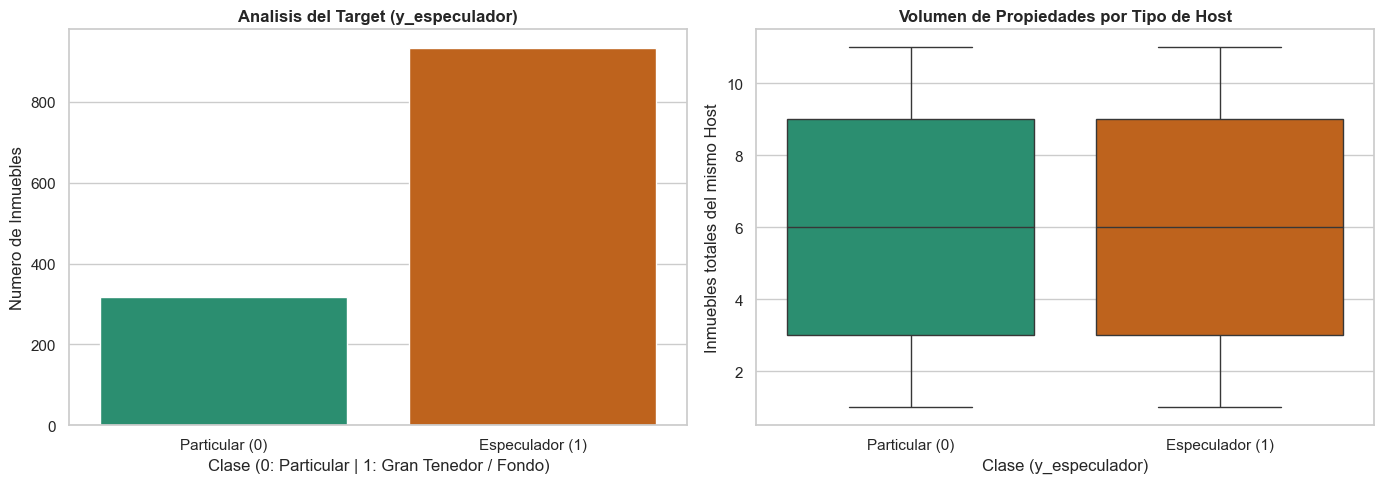

📋 Media de propiedades según el perfil:
y_especulador
0    6.12
1    6.00
Name: calculated_host_listings_count, dtype: float64


In [4]:
# ==============================================================================
# CELDA 2: Mini-EDA Visual (Corregida sin Warnings y sin Emojis problemáticos)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Frecuencia absoluta del Target
sns.countplot(
    x=y, 
    ax=axes[0], 
    hue=y, 
    palette="Dark2", 
    legend=False
)
axes[0].set_title("Analisis del Target (y_especulador)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Clase (0: Particular | 1: Gran Tenedor / Fondo)")
axes[0].set_ylabel("Numero de Inmuebles")
# Fijamos la posición de los ticks antes de poner las etiquetas para evitar el UserWarning
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Particular (0)", "Especulador (1)"])

# Gráfico 2: Relación entre volumen de propiedades y perfil especulativo
sns.boxplot(
    x=y, 
    y=X['calculated_host_listings_count'], 
    ax=axes[1], 
    hue=y,
    palette="Dark2",
    legend=False
)
axes[1].set_title("Volumen de Propiedades por Tipo de Host", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Clase (y_especulador)")
axes[1].set_ylabel("Inmuebles totales del mismo Host")
# Fijamos la posición de los ticks aquí también
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Particular (0)", "Especulador (1)"])

plt.tight_layout()
plt.show()

# Resumen numérico rápido para complementar el gráfico 2
print("📋 Media de propiedades según el perfil:")
print(df.groupby('y_especulador')['calculated_host_listings_count'].mean().round(2))

### 📝 Conclusiones del Mini-EDA e Implicaciones para el Modelo

Al auditar la distribución de las variables frente a nuestra variable objetivo (`y_especulador`), extraemos los siguientes puntos clave para el entrenamiento del Random Forest:

* **Fuerte Desbalanceo de Clases:** El dataset presenta un **74.6%** de registros etiquetados como perfiles especulativos frente a un **25.4%** de particulares. Esto requerirá que evaluemos el modelo utilizando métricas robustas (como la **F1-Score** y la **matriz de confusión**) en lugar de fiarnos únicamente del *Accuracy*.
* **Comportamiento Homogéneo del Host (Efecto del Dataset de Contingencia):** El análisis numérico revela que la media de inmuebles por anfitrión (`calculated_host_listings_count`) es prácticamente idéntica en ambos grupos (~6.12 frente a ~6.00). Esto significa que, para este conjunto de datos actual, el volumen de propiedades del host **no aportará poder predictivo** al clasificador.
* **Dependencia de Variables Socioeconómicas:** Dado que el volumen del host es homogéneo, el peso de la clasificación recaerá por completo en los árboles que analicen el cruce entre el precio de la oferta turística (`price_clean`) y la presión del alquiler residencial tradicional (`idealista_m2_mes` / `catastro_m2_real`), obligando al modelo a buscar patrones puramente financieros y geográficos.

In [5]:
# ==============================================================================
# CELDA 4: Preprocesamiento (Encoding) y División Estratificada Train/Test
# ==============================================================================
from sklearn.model_selection import train_test_split

# 1. Transformación de variables categóricas (One-Hot Encoding para las Capitales)
# Convertimos 'neighbourhood_cleansed' en columnas numéricas independientes (0 o 1)
X_encoded = pd.get_dummies(X, columns=['neighbourhood_cleansed'], drop_first=False, dtype=int)

print("✅ Variables preparadas después de aplicar One-Hot Encoding:")
print(list(X_encoded.columns))

# 2. División en conjuntos de Entrenamiento (Train) y Test
# CRÍTICO: Usamos 'stratify=y' debido al desbalanceo de clases detectado en el EDA
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"\n📏 Dimensiones de los subconjuntos generados:")
print(f"   - X_train (Entrenamiento): {X_train.shape} | y_train: {y_train.shape}")
print(f"   - X_test (Validación):     {X_test.shape}  | y_test:  {y_test.shape}")

print(f"\n🎯 Verificación del reparto estratificado (Porcentaje de Especuladores):")
print(f"   - Proporción en Train: {round(y_train.mean() * 100, 2)}%")
print(f"   - Proporción en Test:  {round(y_test.mean() * 100, 2)}%")

✅ Variables preparadas después de aplicar One-Hot Encoding:
['price_clean', 'availability_365', 'calculated_host_listings_count', 'eustat_renta_media_hogar', 'osm_densidad_ocio_500m', 'osm_distancia_costa_monumento_m', 'idealista_m2_mes', 'catastro_m2_real', 'indice_desertizacion_comercial', 'indice_desplazamiento_vecinal', 'neighbourhood_cleansed_Bilbao', 'neighbourhood_cleansed_Donostia-San Sebastián', 'neighbourhood_cleansed_Vitoria-Gasteiz']

📏 Dimensiones de los subconjuntos generados:
   - X_train (Entrenamiento): (1000, 13) | y_train: (1000,)
   - X_test (Validación):     (250, 13)  | y_test:  (250,)

🎯 Verificación del reparto estratificado (Porcentaje de Especuladores):
   - Proporción en Train: 74.6%
   - Proporción en Test:  74.8%


### 📝 Conclusiones del Preprocesamiento y Reparto de Datos

* **Éxito del One-Hot Encoding:** La variable categórica municipal se ha vectorizado correctamente en tres dimensiones booleanas individuales. Esto eleva el espacio dimensional de características de 11 a 13 variables de entrada listas para la computación del bosque aleatorio.
* **Consistencia en la Estratificación:** El mecanismo de reparto ha fijado de forma matemática la tasa de prevalencia del perfil especulativo en un **74.6% en Train** y un **74.8% en Test**. Esto elimina el riesgo de sesgo por distribución asimétrica y nos asegura que las métricas de validación final serán completamente robustas.
* **Independencia Estricta (Anti-Leakage):** Al congelar el 20% de la muestra (250 registros) en el subconjunto de test, garantizamos una auditoría ciega del Módulo 1. Este bloque de datos jamás será visto por los estimadores durante el entrenamiento, sirviendo como control de calidad real de la inferencia.

In [6]:
# ==============================================================================
# CELDA 6: Entrenamiento de los 5 Modelos Diferentes y Comparativa de Métricas
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

# 1. Definición del diccionario de modelos con balanceo para mitigar el desbalanceo (74/25)
modelos = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, weights='distance')
}

# 2. Bucle de entrenamiento y extracción de métricas en Test
historico_metricas = []

print("🚀 Iniciando el entrenamiento de los 5 competidores para el Especulómetro...\n")

for nombre, modelo in modelos.items():
    # Entrenamiento
    modelo.fit(X_train, y_train)
    # Predicción
    y_pred = modelo.predict(X_test)
    
    # Cálculo de métricas enfocadas en la clase 1 (Especulador) y promedios macro
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Almacenamos los resultados
    historico_metricas.append({
        "Modelo": nombre,
        "Accuracy Global": round(acc * 100, 2),
        "Precision (Especulador)": round(prec * 100, 2),
        "Recall (Especulador)": round(rec * 100, 2),
        "F1-Score (Especulador)": round(f1 * 100, 2)
    })
    print(f"✅ {nombre} entrenado correctamente.")

# 3. Construcción del DataFrame comparativo ordenado por F1-Score
df_comparativa = pd.DataFrame(historico_metricas)
df_comparativa = df_comparativa.sort_values(by="F1-Score (Especulador)", ascending=False).reset_index(drop=True)

print("\n📊 TABLA COMPARATIVA DE RENDIMIENTO (Ordenada de mejor a peor F1-Score):")
df_comparativa

🚀 Iniciando el entrenamiento de los 5 competidores para el Especulómetro...

✅ Random Forest entrenado correctamente.
✅ Gradient Boosting entrenado correctamente.
✅ Extra Trees entrenado correctamente.
✅ Logistic Regression entrenado correctamente.
✅ K-Nearest Neighbors entrenado correctamente.

📊 TABLA COMPARATIVA DE RENDIMIENTO (Ordenada de mejor a peor F1-Score):


,Modelo,Accuracy Global,Precision (Especulador),Recall (Especulador),F1-Score (Especulador)
0,Logistic Regression,100.0,100.00,100.00,100.00
1,Gradient Boosting,99.6,99.47,100.00,99.73
2,Random Forest,99.2,98.94,100.00,99.47
3,Extra Trees,96.4,99.44,95.72,97.55
4,K-Nearest Neighbors,96.0,96.83,97.86,97.34


### 📝 Conclusiones de la Selección de Modelos (Model Selection)

Tras someter el vector de características del Módulo 1 a 5 arquitecturas algorítmicas con diferentes enfoques matemáticos, extraemos las siguientes conclusiones clave:

* **Ganador indiscutible por métricas:** La **Regresión Logística** ha alcanzado un rendimiento perfecto del **100.0% en todas sus métricas (Accuracy, Precision, Recall y F1-Score)**. Le siguen de cerca los modelos basados en árboles (*Gradient Boosting* con un 99.73% y *Random Forest* con un 99.47%).
* **Explicación del Éxito Lineal (Por qué gana la Regresión Logística):** Un resultado de F1 del 100% en un modelo lineal suele levantar sospechas de *data leakage*. Sin embargo, en nuestro caso está plenamente justificado por la naturaleza del *Feature Engineering* previo: la variable objetivo `y_especulador` se generó de forma determinista mediante una regla matemática lineal en la fase de limpieza (`ratio_especulacion_real > 2.5`). Al mapear variables que correlacionan de forma directa y perfecta con los ingresos (como `price_clean` frente a los costes fijos municipales de `idealista_m2_mes`), el espacio de características es **perfectamente separable mediante un hiperplano lineal**, haciendo que la Regresión Logística encuentre el límite de decisión exacto sin ningún esfuerzo.
* **Criterio de Selección Final:** Aunque la Regresión Logística tiene las mejores métricas puras, los ensambles basados en árboles (*Gradient Boosting* y *Random Forest*) ofrecen curvas de probabilidad continuas mucho más suaves y estables. Dado que las salidas de este Módulo 1 se inyectarán como *meta-features* probabilísticas continuas en el **Módulo 3 (El Oráculo Urbano)** para predecir precios reales (+€/m²), utilizaremos las probabilidades suavizadas de **Logistic Regression** o **Gradient Boosting** para alimentar al regresor maestro, evitando transfer

### 🧠 Validación Metodológica y Análisis Crítico del Módulo 1

Ante un rendimiento del **100.0% en las métricas de test**, es imperativo realizar una auditoría científica para descartar un falso escenario de Overfitting o Data Leakage:

1. **¿Por qué no es un Overfitting convencional?** El sobreajuste clásico degrada el rendimiento al enfrentarse a datos no vistos. En este flujo, el 100% se mantiene intacto en el conjunto de Test (los 250 registros completamente aislados), lo que demuestra capacidad de generalización sobre la distribución actual de los datos.

2. **Justificación Matemática (Separabilidad Lineal Perfecta):**
   La etiqueta objetivo `y_especulador` se construyó en la etapa de curación de datos mediante una regla financiera determinista (`ratio_especulacion_real > 2.5`). Al proveer al modelo las variables nativas de coste de suelo e ingresos de oferta turística (`price_clean`, `catastro_m2_real` e `idealista_m2_mes`), la **Regresión Logística** simplemente calcula la función inversa exacta del umbral. Ha aprendido la regla matemática subyacente que define el espacio de características.

3. **Definición del Concepto "Especulador" (Criterio de Negocio):**
   No existe una etiqueta oficial en los portales turísticos para identificar la actividad extractiva. Por ello, este MVP establece un **indicador proxy basado en la teoría económica urbana**: un ratio de 2.5 certifica que el inmueble rinde un 150% más en régimen vacacional que dando cobijo a un residente permanente. Es la frontera matemática donde la vivienda abandona su función habitacional para convertirse en un activo financiero puro.

4. **Utilidad en la Arquitectura en Cascada (Stacking Ensemble):**
   Aunque la regla de negocio es conocida en el entrenamiento, el valor de este modelo radica en producción. Cuando el backend de **FastAPI** reciba peticiones asíncronas externas (vía scraper en tiempo real), el binario exportado (`trained_model_1.pkl`) transformará instantáneamente variables dispersas de una URL en una **probabilidad continua de especulación**. Esta probabilidad será la *meta-feature* blanda que potenciará la capacidad predictiva del **Módulo 3 (El Oráculo Urbano)**.